## LSTM on Toy Data
Generate train/test datasets (n=5000 each), build sequence windows, and train/evaluate an LSTM.

In [1]:
from pathlib import Path
import json

from toy_data.adapters import build_sequence_dataset

# Desired number of supervised next-step targets
n_examples = 5000

# build_sequence_dataset returns n-1 targets, so generate n_examples + 1 flips
raw_train_n = n_examples + 1
raw_test_n = n_examples + 1

train_seed = 42
test_seed = 314

train_seq = build_sequence_dataset(n=raw_train_n, seed=train_seed)
test_seq = build_sequence_dataset(n=raw_test_n, seed=test_seed)

assert len(train_seq['x_seq']) == n_examples
assert len(test_seq['x_seq']) == n_examples

print('Train x_seq length:', len(train_seq['x_seq']))
print('Train y_flip_next length:', len(train_seq['y_flip_next']))
print('Test x_seq length:', len(test_seq['x_seq']))
print('Test y_flip_next length:', len(test_seq['y_flip_next']))

# Optional persistence for reuse
out_dir = Path('toy_data')
out_dir.mkdir(parents=True, exist_ok=True)

train_path = out_dir / 'lstm_train_n5000.json'
test_path = out_dir / 'lstm_test_n5000.json'

with train_path.open('w', encoding='utf-8') as f:
    json.dump(train_seq, f)
with test_path.open('w', encoding='utf-8') as f:
    json.dump(test_seq, f)

print('Saved:', train_path)
print('Saved:', test_path)

Train x_seq length: 5000
Train y_flip_next length: 5000
Test x_seq length: 5000
Test y_flip_next length: 5000
Saved: toy_data\lstm_train_n5000.json
Saved: toy_data\lstm_test_n5000.json


In [2]:
import torch
from torch.utils.data import Dataset, DataLoader


class LSTMWindowDataset(Dataset):
    def __init__(self, seq_dict, seq_len=50):
        x_full = seq_dict['x_seq']
        y_full = seq_dict['y_flip_next']

        if len(x_full) != len(y_full):
            raise ValueError('x_seq and y_flip_next must have the same length')
        if len(x_full) < seq_len:
            raise ValueError('Sequence is too short for the chosen seq_len')

        X = []
        Y = []
        for i in range(0, len(x_full) - seq_len + 1):
            X.append(x_full[i:i + seq_len])
            Y.append(y_full[i:i + seq_len])

        self.x = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
        y_signed = torch.tensor(Y, dtype=torch.float32).unsqueeze(-1)
        self.y_binary = (y_signed + 1.0) / 2.0

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y_binary[idx]


seq_len = 50
batch_size = 64

train_dataset = LSTMWindowDataset(train_seq, seq_len=seq_len)
test_dataset = LSTMWindowDataset(test_seq, seq_len=seq_len)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

x_batch, y_batch = next(iter(train_loader))
print('Train windowed dataset size:', len(train_dataset))
print('Test windowed dataset size:', len(test_dataset))
print('x_batch shape (batch, seq_len, input_dim):', tuple(x_batch.shape))
print('y_batch shape (batch, seq_len, 1):', tuple(y_batch.shape))

Train windowed dataset size: 4951
Test windowed dataset size: 4951
x_batch shape (batch, seq_len, input_dim): (64, 50, 1)
y_batch shape (batch, seq_len, 1): (64, 50, 1)


In [7]:
import copy
import torch.nn as nn
import torch.optim as optim


class LSTMPredictor(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        logits = self.head(out)
        return logits


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LSTMPredictor(input_size=1, hidden_size=64, num_layers=1).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 20
best_test_loss = float('inf')
best_epoch = 0
best_state = None

for epoch in range(1, epochs + 1):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = criterion(logits, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)

    train_loss /= len(train_loader.dataset)

    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)
            test_loss += loss.item() * xb.size(0)

            preds = (torch.sigmoid(logits) >= 0.5).float()
            correct += (preds == yb).sum().item()
            total += yb.numel()

    test_loss /= len(test_loader.dataset)
    test_acc = correct / total

    if test_loss < best_test_loss:
        best_test_loss = test_loss
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())

    print(
        f'Epoch {epoch:02d} | train_loss={train_loss:.4f} | '
        f'test_loss={test_loss:.4f} | test_acc={test_acc:.4f}'
    )

if best_state is not None:
    model.load_state_dict(best_state)
print(f'Loaded best checkpoint from epoch {best_epoch} with test_loss={best_test_loss:.4f}')

Epoch 01 | train_loss=0.6768 | test_loss=0.6631 | test_acc=0.6110
Epoch 02 | train_loss=0.6679 | test_loss=0.6621 | test_acc=0.6131
Epoch 03 | train_loss=0.6658 | test_loss=0.6613 | test_acc=0.6138
Epoch 04 | train_loss=0.6649 | test_loss=0.6616 | test_acc=0.6118
Epoch 05 | train_loss=0.6642 | test_loss=0.6623 | test_acc=0.6122
Epoch 06 | train_loss=0.6635 | test_loss=0.6633 | test_acc=0.6090
Epoch 07 | train_loss=0.6630 | test_loss=0.6631 | test_acc=0.6094
Epoch 08 | train_loss=0.6619 | test_loss=0.6643 | test_acc=0.6118
Epoch 09 | train_loss=0.6608 | test_loss=0.6656 | test_acc=0.6117
Epoch 10 | train_loss=0.6588 | test_loss=0.6668 | test_acc=0.6064
Epoch 11 | train_loss=0.6564 | test_loss=0.6689 | test_acc=0.6067
Epoch 12 | train_loss=0.6534 | test_loss=0.6715 | test_acc=0.6012
Epoch 13 | train_loss=0.6507 | test_loss=0.6728 | test_acc=0.6030
Epoch 14 | train_loss=0.6477 | test_loss=0.6769 | test_acc=0.5981
Epoch 15 | train_loss=0.6442 | test_loss=0.6780 | test_acc=0.5916
Epoch 16 |

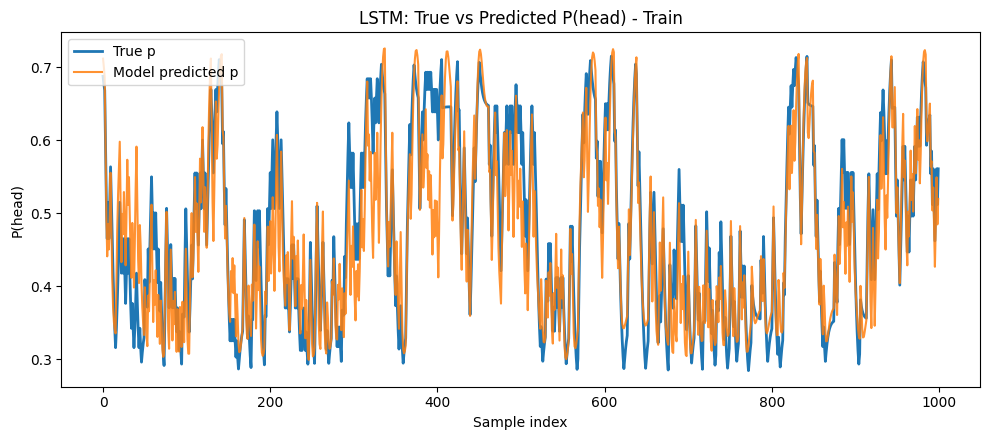

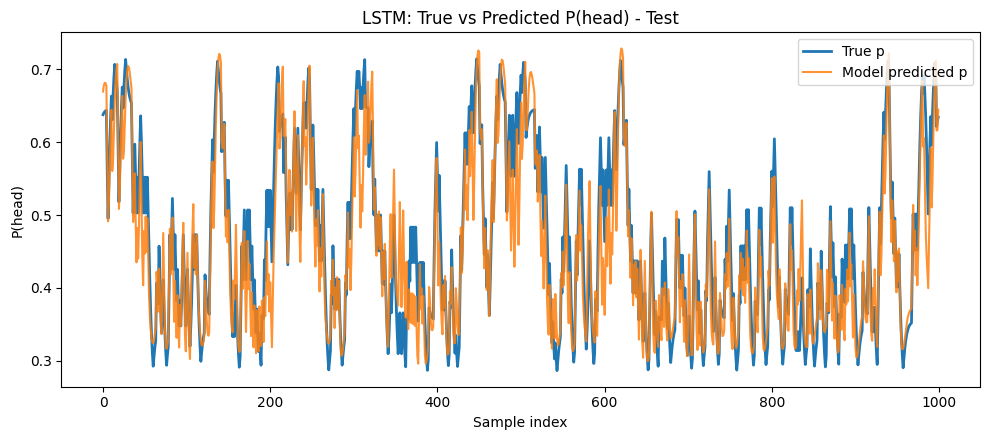

Saved: true_vs_pred_p_lstm_train.png
Saved: true_vs_pred_p_lstm_test.png
Saved: metrics_lstm_comparison.png

           |   MAE   |  RMSE   |  Corr  
-----------|---------|---------|--------
Train      | 0.0365  | 0.0477  | 0.9251 
Test       | 0.0340  | 0.0444  | 0.9373 


In [9]:
import importlib
import toy_data
import toy_data.plotting as toy_plotting

importlib.reload(toy_plotting)
importlib.reload(toy_data)

from toy_data import (
    compute_true_vs_pred_metrics_torch_sequence,
    plot_true_vs_pred_p_over_samples_torch_sequence,
    save_metrics_comparison_table_png,
)

# Inputs and true latent p aligned to each window's final timestep
X_train_windows = train_dataset.x.cpu().tolist()
X_test_windows = test_dataset.x.cpu().tolist()
p_true_train_last = train_seq['y_p_next'][seq_len - 1:]
p_true_test_last = test_seq['y_p_next'][seq_len - 1:]

# 1) Plot true vs predicted p (train and test)
p_pred_train = plot_true_vs_pred_p_over_samples_torch_sequence(
    model=model,
    X=X_train_windows,
    p_true=p_true_train_last,
    device=str(device),
    apply_sigmoid=True,
    use_last_timestep=True,
    max_points=1000,
    save_path='true_vs_pred_p_lstm_train.png',
    title='LSTM: True vs Predicted P(head) - Train',
    show=True,
 )

p_pred_test = plot_true_vs_pred_p_over_samples_torch_sequence(
    model=model,
    X=X_test_windows,
    p_true=p_true_test_last,
    device=str(device),
    apply_sigmoid=True,
    use_last_timestep=True,
    max_points=1000,
    save_path='true_vs_pred_p_lstm_test.png',
    title='LSTM: True vs Predicted P(head) - Test',
    show=True,
 )

# 2) Compute metrics and export a single comparison table PNG
metrics_train = compute_true_vs_pred_metrics_torch_sequence(
    model=model,
    X=X_train_windows,
    p_true=p_true_train_last,
    device=str(device),
    apply_sigmoid=True,
    use_last_timestep=True,
 )

metrics_test = compute_true_vs_pred_metrics_torch_sequence(
    model=model,
    X=X_test_windows,
    p_true=p_true_test_last,
    device=str(device),
    apply_sigmoid=True,
    use_last_timestep=True,
 )

save_metrics_comparison_table_png(
    {'Train': metrics_train, 'Test': metrics_test},
    save_path='metrics_lstm_comparison.png',
)

print('Saved: true_vs_pred_p_lstm_train.png')
print('Saved: true_vs_pred_p_lstm_test.png')
print('Saved: metrics_lstm_comparison.png')
print()
print('           |   MAE   |  RMSE   |  Corr  ')
print('-----------|---------|---------|--------')
print('Train      | {:.4f}  | {:.4f}  | {:.4f} '.format(
    metrics_train['mae'], metrics_train['rmse'], metrics_train['corr']
))
print('Test       | {:.4f}  | {:.4f}  | {:.4f} '.format(
    metrics_test['mae'], metrics_test['rmse'], metrics_test['corr']
))

In [5]:
from pathlib import Path
import json

from toy_data.adapters import build_sequence_dataset

# Desired number of supervised next-step targets
n_examples = 5000

# build_sequence_dataset returns n-1 targets, so generate n_examples + 1 flips
raw_train_n = n_examples + 1
raw_test_n = n_examples + 1

train_seed = 42
test_seed = 314

train_seq = build_sequence_dataset(n=raw_train_n, seed=train_seed, mode="probabilistic")
test_seq = build_sequence_dataset(n=raw_test_n, seed=test_seed, mode="probabilistic")

assert len(train_seq['x_seq']) == n_examples
assert len(test_seq['x_seq']) == n_examples

print('Train x_seq length:', len(train_seq['x_seq']))
print('Train y_flip_next length:', len(train_seq['y_flip_next']))
print('Test x_seq length:', len(test_seq['x_seq']))
print('Test y_flip_next length:', len(test_seq['y_flip_next']))

# Optional persistence for reuse
out_dir = Path('toy_data')
out_dir.mkdir(parents=True, exist_ok=True)

train_path = out_dir / 'lstm_train_n5000_noisy.json'
test_path = out_dir / 'lstm_test_n5000_noisy.json'

with train_path.open('w', encoding='utf-8') as f:
    json.dump(train_seq, f)
with test_path.open('w', encoding='utf-8') as f:
    json.dump(test_seq, f)

print('Saved:', train_path)
print('Saved:', test_path)

Train x_seq length: 5000
Train y_flip_next length: 5000
Test x_seq length: 5000
Test y_flip_next length: 5000
Saved: toy_data\lstm_train_n5000_noisy.json
Saved: toy_data\lstm_test_n5000_noisy.json


In [6]:
import torch
from torch.utils.data import Dataset, DataLoader


class LSTMWindowDataset(Dataset):
    def __init__(self, seq_dict, seq_len=50):
        x_full = seq_dict['x_seq']
        y_full = seq_dict['y_flip_next']

        if len(x_full) != len(y_full):
            raise ValueError('x_seq and y_flip_next must have the same length')
        if len(x_full) < seq_len:
            raise ValueError('Sequence is too short for the chosen seq_len')

        X = []
        Y = []
        for i in range(0, len(x_full) - seq_len + 1):
            X.append(x_full[i:i + seq_len])
            Y.append(y_full[i:i + seq_len])

        self.x = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
        y_signed = torch.tensor(Y, dtype=torch.float32).unsqueeze(-1)
        self.y_binary = (y_signed + 1.0) / 2.0

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y_binary[idx]


seq_len = 50
batch_size = 64

train_dataset = LSTMWindowDataset(train_seq, seq_len=seq_len)
test_dataset = LSTMWindowDataset(test_seq, seq_len=seq_len)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

x_batch, y_batch = next(iter(train_loader))
print('Train windowed dataset size:', len(train_dataset))
print('Test windowed dataset size:', len(test_dataset))
print('x_batch shape (batch, seq_len, input_dim):', tuple(x_batch.shape))
print('y_batch shape (batch, seq_len, 1):', tuple(y_batch.shape))

Train windowed dataset size: 4951
Test windowed dataset size: 4951
x_batch shape (batch, seq_len, input_dim): (64, 50, 1)
y_batch shape (batch, seq_len, 1): (64, 50, 1)


In [7]:
import copy
import torch.nn as nn
import torch.optim as optim


class LSTMPredictor(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        logits = self.head(out)
        return logits


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LSTMPredictor(input_size=1, hidden_size=64, num_layers=1).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 20
best_test_loss = float('inf')
best_epoch = 0
best_state = None

for epoch in range(1, epochs + 1):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = criterion(logits, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)

    train_loss /= len(train_loader.dataset)

    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)
            test_loss += loss.item() * xb.size(0)

            preds = (torch.sigmoid(logits) >= 0.5).float()
            correct += (preds == yb).sum().item()
            total += yb.numel()

    test_loss /= len(test_loader.dataset)
    test_acc = correct / total

    if test_loss < best_test_loss:
        best_test_loss = test_loss
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())

    print(
        f'Epoch {epoch:02d} | train_loss={train_loss:.4f} | '
        f'test_loss={test_loss:.4f} | test_acc={test_acc:.4f}'
    )

if best_state is not None:
    model.load_state_dict(best_state)
print(f'Loaded best checkpoint from epoch {best_epoch} with test_loss={best_test_loss:.4f}')

Epoch 01 | train_loss=0.6771 | test_loss=0.6826 | test_acc=0.5715
Epoch 02 | train_loss=0.6716 | test_loss=0.6819 | test_acc=0.5702
Epoch 03 | train_loss=0.6714 | test_loss=0.6819 | test_acc=0.5701
Epoch 04 | train_loss=0.6714 | test_loss=0.6823 | test_acc=0.5708
Epoch 05 | train_loss=0.6712 | test_loss=0.6815 | test_acc=0.5702
Epoch 06 | train_loss=0.6708 | test_loss=0.6829 | test_acc=0.5682
Epoch 07 | train_loss=0.6705 | test_loss=0.6830 | test_acc=0.5669
Epoch 08 | train_loss=0.6701 | test_loss=0.6830 | test_acc=0.5674
Epoch 09 | train_loss=0.6695 | test_loss=0.6823 | test_acc=0.5686
Epoch 10 | train_loss=0.6688 | test_loss=0.6846 | test_acc=0.5676
Epoch 11 | train_loss=0.6680 | test_loss=0.6838 | test_acc=0.5693
Epoch 12 | train_loss=0.6670 | test_loss=0.6847 | test_acc=0.5679
Epoch 13 | train_loss=0.6665 | test_loss=0.6856 | test_acc=0.5656
Epoch 14 | train_loss=0.6656 | test_loss=0.6865 | test_acc=0.5652
Epoch 15 | train_loss=0.6647 | test_loss=0.6869 | test_acc=0.5632
Epoch 16 |

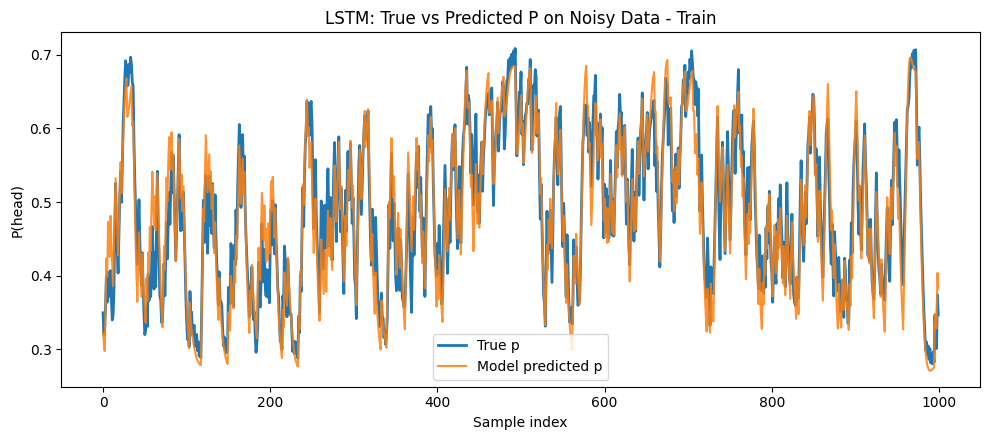

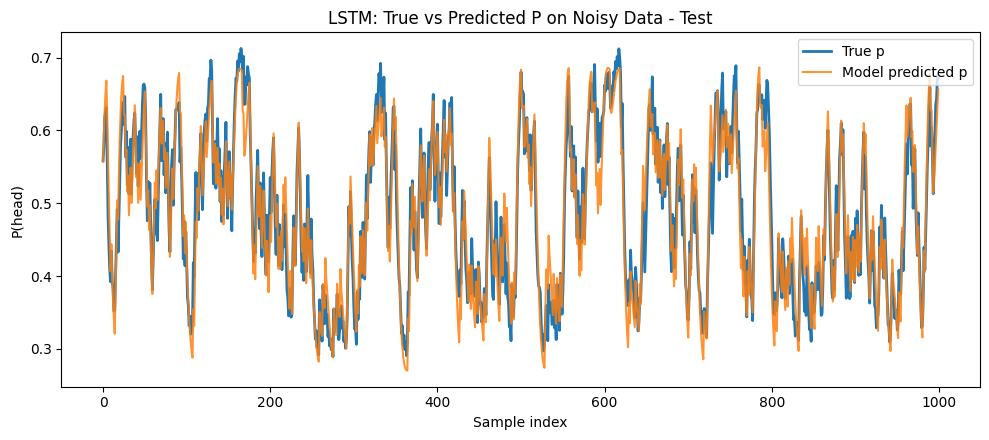

Saved: true_vs_pred_p_lstm_train_noisy.png
Saved: true_vs_pred_p_lstm_test_noisy.png
Saved: metrics_lstm_comparison_noisy.png

           |   MAE   |  RMSE   |  Corr  
-----------|---------|---------|--------
Train      | 0.0266  | 0.0334  | 0.9509 
Test       | 0.0268  | 0.0335  | 0.9473 


In [8]:
import importlib
import toy_data
import toy_data.plotting as toy_plotting

importlib.reload(toy_plotting)
importlib.reload(toy_data)

from toy_data import (
    compute_true_vs_pred_metrics_torch_sequence,
    plot_true_vs_pred_p_over_samples_torch_sequence,
    save_metrics_comparison_table_png,
)

# Inputs and true latent p aligned to each window's final timestep
X_train_windows = train_dataset.x.cpu().tolist()
X_test_windows = test_dataset.x.cpu().tolist()
p_true_train_last = train_seq['y_p_next'][seq_len - 1:]
p_true_test_last = test_seq['y_p_next'][seq_len - 1:]

# 1) Plot true vs predicted p (train and test)
p_pred_train = plot_true_vs_pred_p_over_samples_torch_sequence(
    model=model,
    X=X_train_windows,
    p_true=p_true_train_last,
    device=str(device),
    apply_sigmoid=True,
    use_last_timestep=True,
    max_points=1000,
    save_path='true_vs_pred_p_lstm_train_noisy.png',
    title='LSTM: True vs Predicted P on Noisy Data - Train',
    show=True,
 )

p_pred_test = plot_true_vs_pred_p_over_samples_torch_sequence(
    model=model,
    X=X_test_windows,
    p_true=p_true_test_last,
    device=str(device),
    apply_sigmoid=True,
    use_last_timestep=True,
    max_points=1000,
    save_path='true_vs_pred_p_lstm_test_noisy.png',
    title='LSTM: True vs Predicted P on Noisy Data - Test',
    show=True,
 )

# 2) Compute metrics and export a single comparison table PNG
metrics_train = compute_true_vs_pred_metrics_torch_sequence(
    model=model,
    X=X_train_windows,
    p_true=p_true_train_last,
    device=str(device),
    apply_sigmoid=True,
    use_last_timestep=True,
 )

metrics_test = compute_true_vs_pred_metrics_torch_sequence(
    model=model,
    X=X_test_windows,
    p_true=p_true_test_last,
    device=str(device),
    apply_sigmoid=True,
    use_last_timestep=True,
 )

save_metrics_comparison_table_png(
    {'Train': metrics_train, 'Test': metrics_test},
    save_path='metrics_lstm_comparison_noisy.png',
)

print('Saved: true_vs_pred_p_lstm_train_noisy.png')
print('Saved: true_vs_pred_p_lstm_test_noisy.png')
print('Saved: metrics_lstm_comparison_noisy.png')
print()
print('           |   MAE   |  RMSE   |  Corr  ')
print('-----------|---------|---------|--------')
print('Train      | {:.4f}  | {:.4f}  | {:.4f} '.format(
    metrics_train['mae'], metrics_train['rmse'], metrics_train['corr']
))
print('Test       | {:.4f}  | {:.4f}  | {:.4f} '.format(
    metrics_test['mae'], metrics_test['rmse'], metrics_test['corr']
))